In [79]:
pip install numpy pandas matplotlib seaborn scikit-learn tqdm time

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement time (from versions: none)

[notice] A new release of pip is available: 25.1 -> 25.3
[notice] To update, run: C:\Users\rapha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for time


In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.sparse.linalg import LinearOperator, bicgstab
import time 



In [4]:
x = loadmat('data/x')['x'].ravel()
H = loadmat('data/H')['H']
G = loadmat('data/G')['G']
print(f"x shape: {x.shape}, H shape: {H.shape}, G shape: {G.shape}")


x shape: (8100,), H shape: (16200, 8100), G shape: (16200, 8100)


y shape: (16200,)


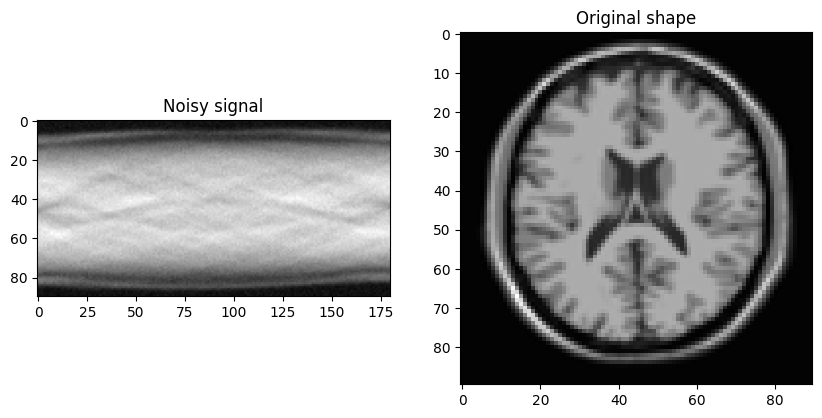

In [11]:
sigma = 1
y = H @ x + sigma * np.random.standard_normal(H.shape[0])
print(f"y shape: {y.shape}")
Y = y.reshape((90,180),order='F')
X = x.reshape((90,90),order='F')

plt.figure(figsize=(10,7))
plt.subplot(1,2,2)
plt.imshow(X, cmap='gray')
plt.title("Original shape")
plt.subplot(1,2,1)
plt.imshow(Y, cmap='gray')
plt.title("Noisy signal")
plt.show()


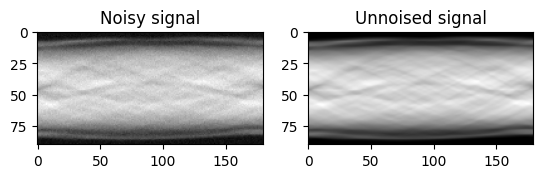

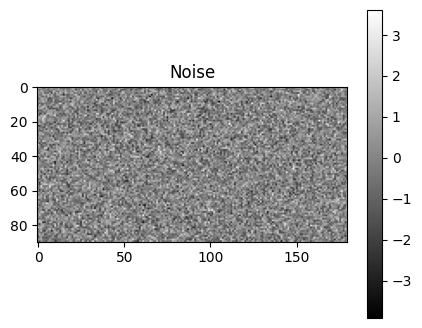

In [15]:
y_opt = H @ x  
Y_OPT = y_opt.reshape((90,180),order='F')
plt.subplot(1,2,2)
plt.imshow(Y_OPT, cmap='gray')
plt.title("Unnoised signal")
plt.subplot(1,2,1)
plt.imshow(Y, cmap='gray')
plt.title("Noisy signal")
plt.show()
plt.show()

plt.figure(figsize=(5,4))
plt.imshow(Y - Y_OPT, cmap='gray')
plt.title("Noise")
plt.colorbar()
plt.show()

### Gradient de f
$$x \in \R^N, G \in \R^{2N \times N}$$
$$f(x) = \frac{1}{2}||Hx - y||^2 + \lambda r(x)$$
$$r(x) = \sum_{n=1}^{2N}{\psi([Gx]^{(n)})} = \mathbb{1}^T\psi(Gx)$$
$$\psi(u) = \sqrt{1+\frac{u^2}{\delta^2}} $$

D'abord :
$$\nabla f(x) =  H^T (Hx-y) + \lambda \nabla r(x)  $$
puis on calcul la dérivée de psi :
$$\psi '(u) = \frac{u}{\delta^2 \sqrt{1+\frac{u^2}{\delta^2}}} = \frac{u}{\delta \sqrt{\delta^2+u^2}} = \frac{1}{\delta \sqrt{\frac{\delta^2}{u^2}+1}} $$
puis on compose :

$$\nabla_{x}r(x) = G^T\psi '(Gx) = G^T[\frac{1}{\delta \sqrt{\frac{\delta^2}{[Gx]_{(n)}^2}+1}}]_{1<n<2N}$$
Et enfin : 

$$\nabla f(x) =  H^T (Hx-y) + \lambda G^T[\frac{1}{\delta \sqrt{\frac{\delta^2}{[Gx]_{(n)}^2}+1}}]_{1<n<2N} =  H^T (Hx-y) + \lambda G^T[\frac{[Gx]_{(n)}}{\delta^2 \sqrt{\frac{[Gx]_{(n)}^2}{\delta^2}+1}}]_{1<n<2N}  $$

In [121]:
lamb, delta = 0.13,0.02
def f(x):
    return 0.5 * np.linalg.norm(H @ x - y)**2 + lamb * np.sum(np.sqrt(1 +((G @ x)**2 / delta**2)))
def grad_f(x):
    return H.T @ (H @ x - y) + lamb * G.T @ (G @ x / (delta * np.sqrt(delta**2 + (G @ x)**2)))


    

### Lipschitz constant

Le premier terme du gradient a une constante de lipschitz évidente : $||H||^2$.
Calculons la hésienne de r pour le second terme.
$$\psi'' = \frac{\delta^2 \sqrt{\frac{u^2}{\delta^2}+1} - u^2/\sqrt{\frac{u^2}{\delta^2}+1}}{\delta^4 (\frac{u^2}{\delta^2}+1)} =  \frac{\delta^2 (\frac{u^2}{\delta^2}+1)- u^2}{\delta^4 (\frac{u^2}{\delta^2}+1)^{3/2}} = \frac{1}{\delta^2 (1 +\frac{u^2}{\delta^2})^{3/2}} $$

On a $\nabla r(x) = G^T\psi'(Gx)$ donc $\nabla^2r(x) = G^Tdiag(\psi''(Gx))G $ et comme $\psi'' \leq 1/ \delta^2$ il vient :
$$||\nabla^2r(x) ||\leq ||G||^2 / \delta^2$$

Donc au final la constante de lipschitz est : $$ ||H||^2+ \lambda ||G||^2 / \delta^2$$

In [17]:
from scipy.sparse.linalg import svds
def max_sv(A):
    """Compute the largest singular value of matrix A using sparse SVD."""
    return svds(A,k=1,which='LM',return_singular_vectors=False)[0]

lipschitz_const = max_sv(H)**2 + lamb * (max_sv(G)**2)/(delta**2)
print(f"Lipschitz constant estimate: {lipschitz_const}")

Lipschitz constant estimate: 18092.773276864806


In [119]:
def gradient_descent(x0,n_iter=1000,gamma_factor=1.5, lipschitz_const=lipschitz_const):
    xn = x0.copy()
    f_history = []
    time_history = []
    start_time = time.time()
    xn1 = xn
    gamma= gamma_factor / lipschitz_const
    treshold = np.sqrt(len(xn)) * 1e-4
    for n in range(n_iter):
        f_history.append(f(xn))
        time_history.append(time.time() - start_time)
        grad_xn = grad_f(xn)
        xn1 = xn - gamma * grad_xn
        resid = np.linalg.norm( grad_xn)
        if resid < treshold:
            xn = xn1
            print(f"Converged in {n} iterations with residual {resid}")
            break
        xn = xn1
    print(f"Did not converge in {n_iter} iterations, final residual {resid}")
    return xn , f_history, time_history

Did not converge in 1000 iterations, final residual 0.0028846596777002587
Did not converge in 1000 iterations, final residual 0.0007918203345846363
Did not converge in 1000 iterations, final residual 0.00032480611606179057
Did not converge in 1000 iterations, final residual 9.082258193874136e-05
Did not converge in 500 iterations, final residual 0.00803042115773229
Did not converge in 2000 iterations, final residual 4.636113894457706e-06
Did not converge in 3000 iterations, final residual 0.00040748002890611


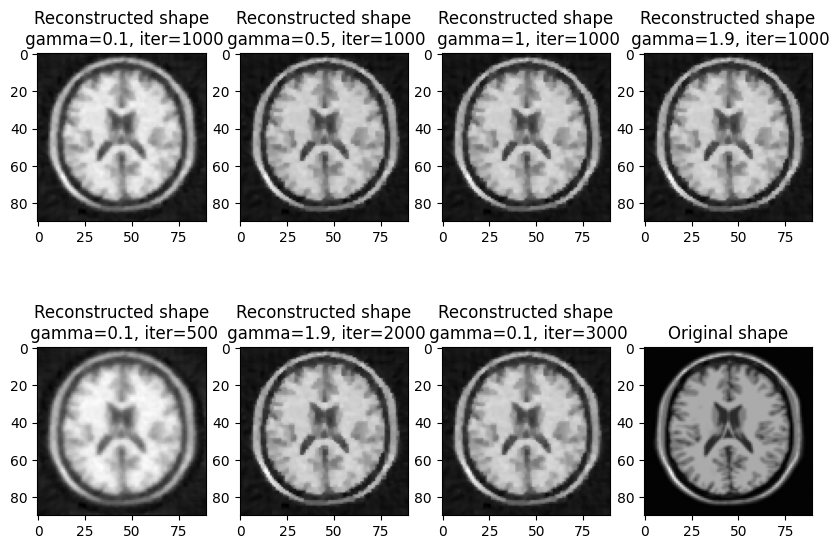

In [ ]:
plt.figure(figsize=(10,7))
grid_para = [(0.1,1000),(0.5,1000),(1,1000),(1.9,1000)]
for i,(gamma_factor, n_iter) in enumerate(grid_para):
    x0 = np.zeros_like(x)
    x_est, _,_ = gradient_descent(x0, gamma_factor=gamma_factor,n_iter=n_iter)
    X_est = x_est.reshape((90,90),order='F')
    plt.subplot(2,4,i+1)
    plt.imshow(X_est, cmap='gray')
    plt.title(f"Reconstructed shape\n gamma={gamma_factor}, iter={n_iter}")
    
plt.subplot(2,4,8)
plt.imshow(X, cmap='gray')
plt.title("Original shape")
plt.show()

Il faut beaucoup d'iterations pour un bon résultat.

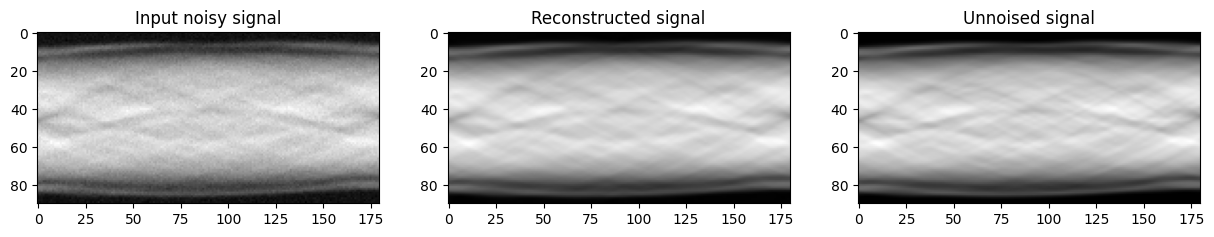

In [ ]:
y_mmg = H @ x_est
Y_mmg = y_mmg.reshape((90,180),order='F')
plt.figure(figsize=(15,7))
plt.subplot(1,3,2)
plt.imshow(Y_mmg, cmap='gray')
plt.title("Reconstructed signal")
plt.subplot(1,3,1)
plt.imshow(Y, cmap='gray')
plt.title("Input noisy signal")
plt.subplot(1,3,3)
plt.imshow(Y_OPT, cmap='gray')
plt.title("Unnoised signal")
plt.show()


### MM algorithm 

$$\nabla^2 f(x) = H^TH + \lambda G^Tdiag(\psi''(Gx))G$$
Posons $A = H^TH + \frac{\lambda}{\delta^2} G^TG$ alors $A - \nabla^2 f(x)$ est semi-définie positive $\forall x \in \mathbb{R}^N$ car les valeurs propres de $\frac{1}{\delta^2}I_{2N}-diag(\psi''(Gx))$ sont positives et A est semi-définie positive.
D'après le cours, $\forall z \in \mathbb{R}^N$ la fonction h définie par :
$$\forall x \in \mathbb{R}^N, h(x,z) = f(z) + \langle \nabla f(z), x - z \rangle+ \frac{1}{2}\ || x - z||_A^2$$
est une fonction majorante de $f$ en $z$.
Son gradient est :
$$\nabla_x h(x,z) = \nabla f(z) + (A^T+A)(x-z)$$


In [ ]:
### Curvature
from scipy.sparse import diags
from scipy.sparse.linalg import LinearOperator, cg, bicg, bicgstab #resolve Ax = b where A is sparse matrix
from tqdm import trange


alpha = lamb / delta**2
n = H.shape[1]

def matvec_A(v):
    return H.T @ (H @ v) + alpha * (G.T @ (G @ v))

curv_A = LinearOperator(
    shape=(n, n),
    matvec=matvec_A,
    dtype=float
)


In [117]:
### MM algorithm with the hessian of f

def mm(x0, n_iter=100, theta=1):
    xn = x0.copy()
    f_history = []
    time_history = []
    start_time = time.time()
    treshold = np.sqrt(len(xn)) * 1e-4
    for n in range(n_iter):
        f_history.append(f(xn))
        time_history.append(time.time() - start_time)
        b = grad_f(xn)
        temp, exit_code = bicgstab(curv_A, b, x0=xn, rtol=1e-6, maxiter=1000)
        xn1 = xn -theta * temp
        resid = np.linalg.norm(b)
        if resid < treshold:
            xn = xn1
            print(f"MM Converged in {n} iterations with residual {resid}")
            break
        xn = xn1
    return xn, f_history, time_history

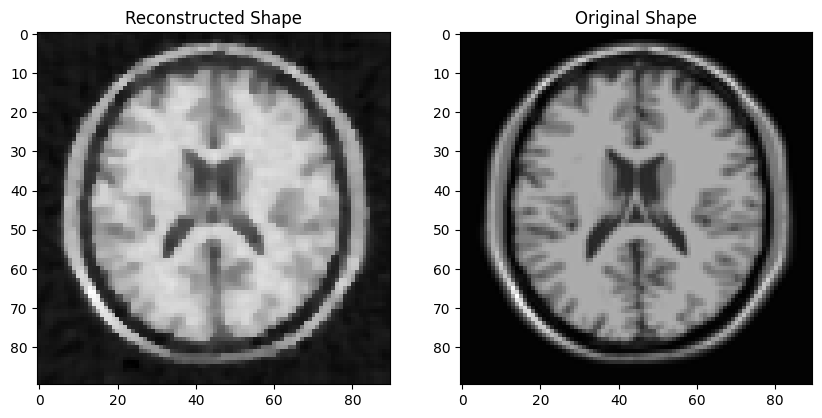

In [ ]:
x0 = np.zeros_like(x)
x_mm, _,_ = mm(x0 ,n_iter=100)
X_mm = x_mm.reshape((90,90),order='F')
plt.figure(figsize=(10,14))
plt.subplot(2,2,2)
plt.imshow(X, cmap='gray')
plt.title("Original Shape")
plt.subplot(2,2,1)
plt.imshow(X_mm, cmap='gray')
plt.title("Reconstructed Shape")
plt.show()
y_mm = H @ x_mm  
Y_mm = y_mm.reshape((90,180),order='F') 


### 3.3 Supspace strategy

In [ ]:
from scipy.linalg import pinv
def mmmg(x0, n_iter=100):
    xn = x0.copy()
    f_history = []
    time_history = []
    start_time = time.time()
    D = - grad_f(xn)
    temp_h = H @ D
    temp_g = G @ D
    temp = (temp_h.T @ temp_h) + alpha * (temp_g.T @  temp_g)
    u = np.array(- 1/temp * (D.T @ grad_f(xn)))
    xn1 = xn + u*D
    treshold = np.sqrt(len(xn)) * 1e-4

    for n in range(n_iter):
        f_history.append(f(xn))
        time_history.append(time.time() - start_time)
        D = np.column_stack((-grad_f(xn1),xn1 - xn))
        xn = xn1
        temp_h = H @ D
        temp_g = G @ D
        u = - pinv((temp_h.T @ temp_h) + alpha * (temp_g.T @ temp_g)) @ (D.T @ grad_f(xn1))
        xn1 = xn + D @ u
        resid = np.linalg.norm(grad_f(xn1))
        if resid < treshold:
            xn = xn1
            print(f"MMMG Converged in {n} iterations with residual {resid}")
            break
    if resid >= treshold:
        print(f"Did not converge in {n_iter} iterations, final residual {resid}")
    return xn1, f_history, time_history

MM_pinv Converged in 333 iterations with residual 0.008834550249874588


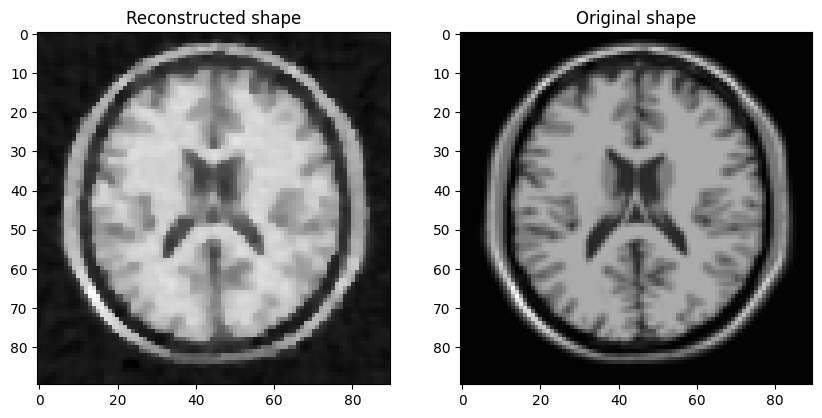

In [128]:
x0 = np.zeros_like(x)
x_mmg,_,_ = mmmg(x0, n_iter=500)
X_mmg = x_mmg.reshape((90,90),order='F')
plt.figure(figsize=(10,7))
plt.subplot(1,2,2)
plt.imshow(X, cmap='gray')
plt.title("Original shape")
plt.subplot(1,2,1)
plt.imshow(X_mmg, cmap='gray')
plt.title("Reconstructed shape")
plt.show()


### 3.4 Block-coordinate MM

In [114]:
def A_block(j, nj):
    n = H.shape[1]
    def matvec(v):
        x = np.zeros(n)
        x[j*nj:(j+1)*nj] = v
        y = H.T @ (H @ x) + alpha * (G.T @ (G @ x))
        return y[j*nj:(j+1)*nj]

    return LinearOperator(shape=(nj, nj),matvec=matvec, dtype=float)


def mm_block(x0, n_iter=10,k=5,theta=1):
    xn = x0.copy()
    xn1 = xn.copy()
    f_history = []
    time_history = []
    start_time = time.time()
    j = 0
    nj = len(xn) // k
    treshold = np.sqrt(len(xn)) * 1e-4
    for n in range(n_iter):
        f_history.append(f(xn))
        time_history.append(time.time() - start_time)
        b = grad_f(xn)[j*nj:(j+1)*nj]
        Aj = A_block(j,nj)
        temp, exit_code = bicgstab(LinearOperator(shape=(nj,nj), matvec=lambda v: Aj @ v), b, x0=xn[j*nj:(j+1)*nj], rtol=1e-6, maxiter=1000)
        xn1[j*nj:(j+1)*nj] = xn[j*nj:(j+1)*nj] -theta * temp
        resid = np.linalg.norm(theta * temp)
        if np.linalg.norm(b) < treshold: 
            xn = xn1
            print(f"MM Block Converged in {n} iterations with residual {resid}")
            break
        xn = xn1
        j = (j + 1) % k
    return xn, f_history, time_history

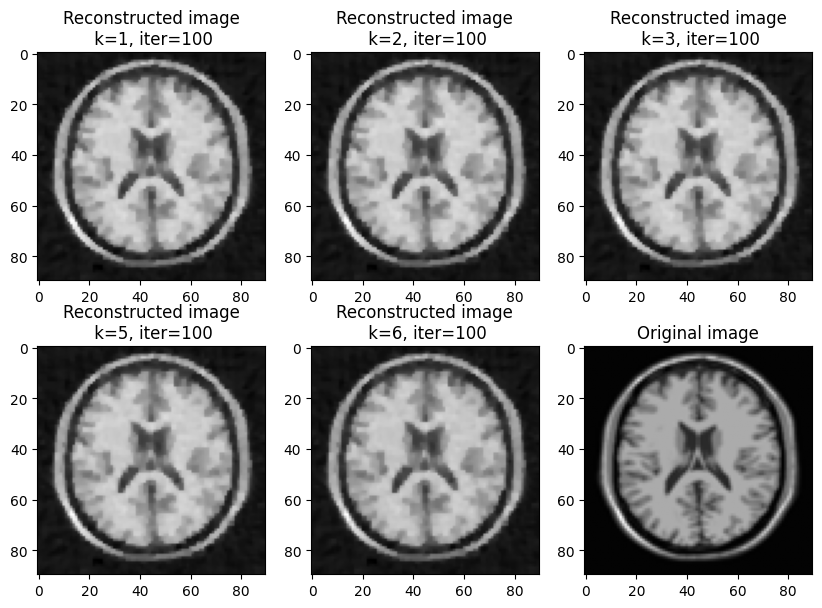

In [ ]:
plt.figure(figsize=(10,7))
grid_k = [1,2,3,5,6,9]
for i,k in enumerate(grid_k):
    x0 = np.zeros_like(x)
    x_est,_,_ = mm_block(x0, n_iter=200, k=k)
    X_est = x_est.reshape((90,90),order='F')
    plt.subplot(2,3,i+1)
    plt.imshow(X_est, cmap='gray')
    plt.title(f"Reconstructed image\n k={k}, iter=100")
    
plt.subplot(2,3,6)
plt.imshow(X, cmap='gray')
plt.title("Original image")
plt.show()

$u \mapsto \frac{-2u}{\delta²(\delta²+u²))^{\frac{3}{2}}}$

### 3.5
Posons $v \in R^N$
$$v^\top A(x) v = \|Hv\|^2 + \frac{\lambda}{\delta^2} \|Gv\|^2 $$
Etudions le premier terme.
$$\|Hv\|^2 = \sum_{m=1}^M \left( \sum_{i=1}^N H_{mi} v_i \right)^2 $$
$$\left( \sum_{i=1}^N H_{mi} v_i \right)^2 \le \left( \sum_{i=1}^N |H_{mi}| |v_i| \right)^2 $$
On introduit ensuite des poids pour appliquer Jensen :
$$\left( \sum_{i=1}^N |H_{mi}| |v_i| \right)^2 = \left( \sum_{i=1}^N \frac{|H_{mi}|}{\sum_{p=1}^N |H_{mp}|} \left( |v_i| \sum_{p=1}^N |H_{mp}| \right) \right)^2 $$
$$\left( \sum_{i=1}^N \frac{|H_{mi}|}{\sum_{p=1}^N |H_{mp}|} \left( |v_i| \sum_{p=1}^N |H_{mp}| \right) \right)^2 \le \sum_{i=1}^N \frac{|H_{mi}|}{\sum_{p=1}^N |H_{mp}|} \left( |v_i| \sum_{p=1}^N |H_{mp}| \right)^2 $$
$$\sum_{i=1}^N \frac{|H_{mi}|}{\sum_{p=1}^N |H_{mp}|} \left( |v_i| \sum_{p=1}^N |H_{mp}| \right)^2 = \sum_{i=1}^N \left( |H_{mi}| \sum_{p=1}^N |H_{mp}| \right) v_i^2 $$
$$\sum_{i=1}^N \left( |H_{mi}| \sum_{p=1}^N |H_{mp}| \right) v_i^2 = \sum_{i=1}^N \mathcal{H}^{(m,i)} v_i^2$$

Donc au final:
$$\|Hv\|^2 \le \sum_{i=1}^N \left( \sum_{m=1}^M \mathcal{H}^{(m,i)} \right) v_i^2 $$
Et de même :
$$\|Gv\|^2 \le \sum_{i=1}^N \left( \sum_{n=1}^{2N} \mathcal{G}^{(n,i)} \right) v_i^2 $$
Donc :
$$v^\top A(x) v \le \sum_{i=1}^N \left( \sum_{m=1}^M \mathcal{H}^{(m,i)} + \frac{\lambda}{\delta^2} \sum_{n=1}^{2N} \mathcal{G}^{(n,i)} \right) v_i^2 $$

D'autre part, 

$$ v^\top B(x) v = \sum_{i=1}^N v_i^2 \mathcal{H}_{(i)}^\top 1 + \lambda v_i^2 \mathcal{G}_{(i)}^\top(\frac{\psi'( Gx)}{Gx}) $$

Il est facile de voir que $\forall u , \psi'(u)/u \le 1/\delta^2 $ ce qui conclue la preuve : 
$$v^\top A v \le v^\top B(x) v $$

In [112]:
def compute_B(H, G):
    abs_H = abs(H)
    row_sums_H = np.array(abs_H.sum(axis=1))
    H_diag_vec = abs_H.T.dot(row_sums_H).flatten()

    abs_G = abs(G)
    row_sums_G = np.array(abs_G.sum(axis=1))
    G_diag_vec = abs_G.T.dot(row_sums_G).flatten()

    B = H_diag_vec + alpha * G_diag_vec
    return B

def parallel_mm(x0, n_iter=1000):
    xn = x0.copy()
    f_history = []  
    time_history = []
    start_time = time.time()
    B = compute_B(H, G)
    stop_threshold = np.sqrt(len(x0)) * 1e-4
    
    for n in range(n_iter):
        f_history.append(f(xn))
        time_history.append(time.time() - start_time)
        grad = grad_f(xn) 
        grad_norm = np.linalg.norm(grad)
        if grad_norm <= stop_threshold:
            print(f"Parallel MM Converged at iteration {n}")
            break
        xn = xn - grad / B
    return xn, f_history, time_history 


In [ ]:

x0, _, _ = np.zeros_like(x)
x_pmm = parallel_mm(x0, n_iter=5000)
X_pmm = x_pmm.reshape((90,90),order='F')
plt.figure(figsize=(10,14))
plt.subplot(2,2,2)
plt.imshow(X, cmap='gray')
plt.title("Original Shape")
plt.subplot(2,2,1)
plt.imshow(X_pmm, cmap='gray')
plt.title("Reconstructed Shape")
plt.show()


Exécution de Gradient...
Did not converge in 2000 iterations, final residual 0.142580246870107
Exécution de MM Parallèle ...
Exécution de 3MG...
MM_pinv Converged in 477 iterations with residual 0.008901287209483294
Exécution de MM Bloc 3...
MM Block Converged in 1687 iterations with residual 4.81436923543173e-06


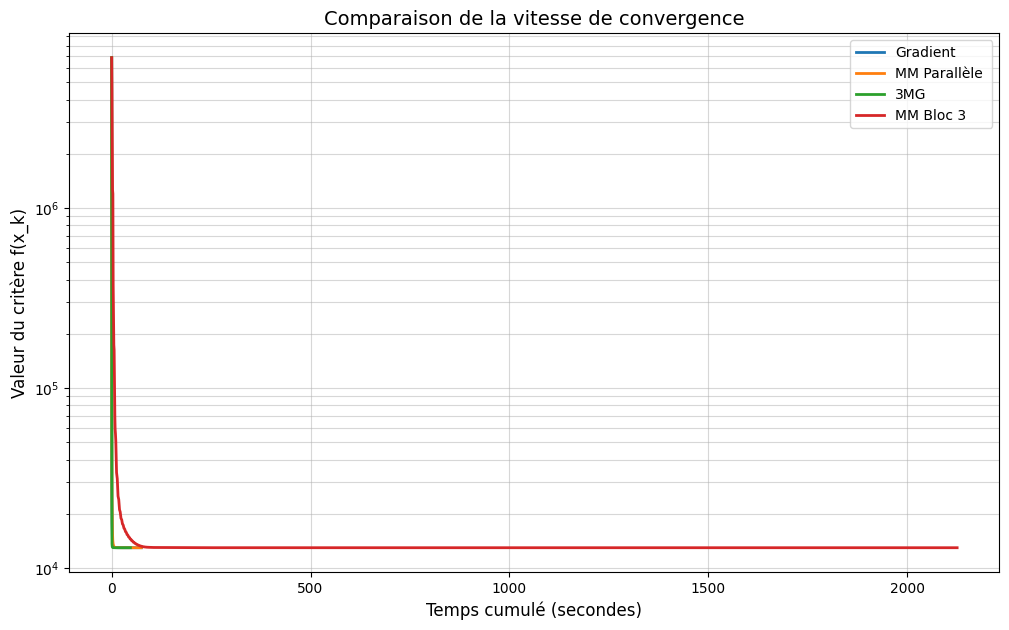

In [125]:

def compare_algorithms(algorithms, x0, n_iter=1000):
    """
    algorithms : dict { "Nom": fonction_algo }
    x0 : initialisation commune
    """
    results = {}
    stop_threshold = np.sqrt(len(x0)) * 1e-4
    
    plt.figure(figsize=(12, 7))
    
    for name, algo_func in algorithms.items():
        print(f"Exécution de {name}...")
        _, f_hist, t_hist = algo_func(x0, n_iter)
        results[name] = (f_hist, t_hist)
        plt.semilogy(t_hist, f_hist, label=name, linewidth=2)
        
    plt.xlabel('Temps cumulé (secondes)', fontsize=12)
    plt.ylabel('Valeur du critère f(x_k)', fontsize=12)
    plt.title('Comparaison de la vitesse de convergence', fontsize=14)
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()
    return results

algos_to_test = {
    "Gradient": gradient_descent,
    # "MM Quadratique ": mm,
    "MM Parallèle ": parallel_mm,
    "3MG": mmmg,
    "MM Bloc 5": mm_block
}
#MM quadratique trop lent à converger
x0 = np.zeros_like(x)
# Lancement de la comparaison
results = compare_algorithms(algos_to_test, x0 , n_iter=2000)

Did not converge in 500 iterations, final residual 15.575997781957183
Did not converge in 500 iterations, final residual 22.770182012675132
Did not converge in 500 iterations, final residual 28.113600520109493
Did not converge in 500 iterations, final residual 32.94699409324923
Did not converge in 500 iterations, final residual 37.402367539314454
Did not converge in 500 iterations, final residual 40.43954659730756
Did not converge in 500 iterations, final residual 0.8964172066372422
Did not converge in 500 iterations, final residual 1.3665322090497323
Did not converge in 500 iterations, final residual 2.092604900085305
Did not converge in 500 iterations, final residual 3.098087193690418
Did not converge in 500 iterations, final residual 4.127086496434771
Did not converge in 500 iterations, final residual 4.969917236558713
Did not converge in 500 iterations, final residual 0.04768456436312239
Did not converge in 500 iterations, final residual 0.09674261720498276
Did not converge in 500 

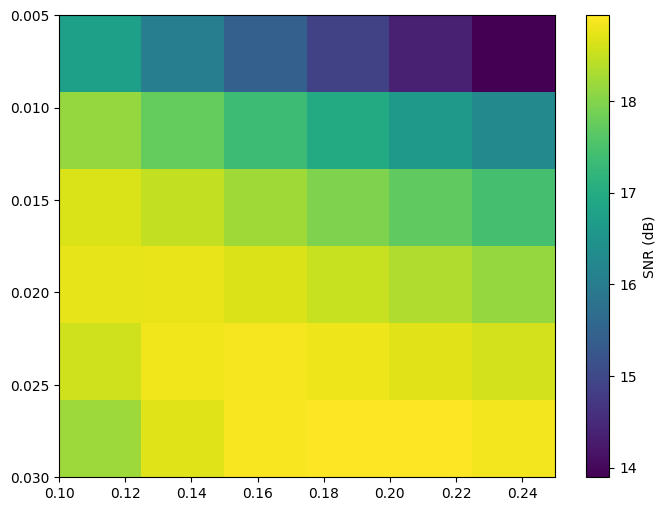

In [126]:
###SNR calculation
grid_delta = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
grid_lamb = [0.1, 0.13, 0.16, 0.19, 0.22, 0.25]
grid_SNR = np.zeros((len(grid_delta), len(grid_lamb)))
for i, delta_ in enumerate(grid_delta):
    for j, lamb_ in enumerate(grid_lamb):
        lamb = lamb_
        delta = delta_
        alpha = lamb / delta**2
        x_mmg,_,_ = mmmg(x0, n_iter=500)
        grid_SNR[i,j] = 10 * np.log10( np.sum(x**2) / np.sum((x - x_mmg)**2) )
plt.figure(figsize=(8,6))
plt.imshow(grid_SNR, extent=[min(grid_lamb), max(grid_lamb), max(grid_delta), min(grid_delta)], aspect='auto', cmap='viridis')
plt.colorbar(label='SNR (dB)')

In [127]:
best_idx = np.unravel_index(np.argmax(grid_SNR, axis=None), grid_SNR.shape)
best_lamb = grid_lamb[best_idx[1]]
best_delta = grid_delta[best_idx[0]]
print(f"Best SNR achieved with lambda={best_lamb} and delta={best_delta}")

Best SNR achieved with lambda=0.19 and delta=0.03
